# Odd or even

A and B show one or two fingers. Even sum: A wins 1, B loses 1. Odd sum: B wins 1, A loses 1.

In [ ]:
#if nashpy is not installed on colab, install it with
#!pip install nashpy

In [ ]:
# !!!! ONLY ON COLAB !!!!
# To use the jupyter books and myNashTools.py on Google Colab, 
#  you need to give access to your personal Google Drive
import sys
import os
from google.colab import drive

#give access to your personal Google Drive (check the authorization, ...)
drive.mount('/content/drive')

# 2. Add the exact path where you put the jupyter books and myNashTools.py
# (Example : if it is in folder the "Colab Notebooks/GameMatrix" on your Drive)
my_folder = '/content/drive/MyDrive/Colab Notebooks/GameMatrix'  # Change this to the path where you put the jupyter books and myNashTools.py
if my_folder not in sys.path: 
    sys.path.insert(0, my_folder)
if os.path.exists(my_folder):
    print(f"OK! the folder exists ! So you can use the jupyter books and myNashTools.py in this folder.")
    fichiers = os.listdir(my_folder)
    print("Content of the folder :", fichiers)    
    # Force insertion of the folder at the beginning of the path
    if my_folder not in sys.path:
        sys.path.insert(0, my_folder)        
else:
    print(f"ERROR: folder does not exist at this path. Verify the spelling or the space.")


In [ ]:
#For all : Colab or your local computer :
import numpy as np, nashpy as nash, matplotlib.pyplot as plt
from myNashTools import print_equilibria, plot_indifference

## Exercise 
Two players "A" and "B" play a little game : they simultaneously show one or two fingers. 
- If the sum is even, player "A" wins 1 point, and B loses 1 point. 
- If the sum is odd, the other player "B" wins 1 and "A" loses 1.

Game matrix

| **A** \ B | one | two |
|---|---|---|
| **one** | (**1**, −1) | (**−1**, 1) |
| **two** | (**−1**, 1) | (**1**, −1) |

In [5]:
acts = ['one', 'two']
game = nash.Game(np.array([[1, -1], [-1, 1]]))   # zero-sum

**Q1.** Find the Nash equilibria in pure strategies.

> **Solution.**  
> **None**: in every cell, the loser would rather change.  
> A chooses *one*, B's interest is on *two*, then A has interest to go on *two*, then B chooses *one* (better choice), next A chooses *one*, etc...  
> OR another explanation:  
> for A : best cells in each column = (0,0), (1,1)  
> for B : best cells in each row = (0,1), (1,0)  
> $bestCellsA \cap bestCellsB = \emptyset $   

**Q2.** Find the mixed-strategy equilibrium.

> **Solution.**   
> let $p$ = Probability A chooses 'one'  
> $E(B|B=one) = -p + (1-p) = 1 - 2.p$  
> $E(B|B=two) = p - (1-p) = -1 + 2p$   
> indifference when $1-2p = -1 + 2p \equiv p = 2/4 = 1/2$  $\Rightarrow$ equilibrium for A $(1/2, 1/2)$   
> by symmetry,  equilibrium for B $(1/2, 1/2)$  
> payoff :   
> | **A** \  B  | one p(1/2) | two p(1/2)|  
> |---|---|---|  
> | **one** p(1/2)| p(1/4) | p(1/4) |  
> | **two** p(1/2)| p(1/4) | p(1/4) |  
> 
> $payoff(A) = 1/4  - 1/4  - 1/4 + 1/4 = 0$  
> $payoff(B) = 0$ (symmetry)

**Check with nashpy**

In [6]:
print_equilibria(game, acts, acts)

Equilibrium 1:  A -> [one: 1/2, two: 1/2]   B -> [one: 1/2, two: 1/2]   payoffs = (0, 0)


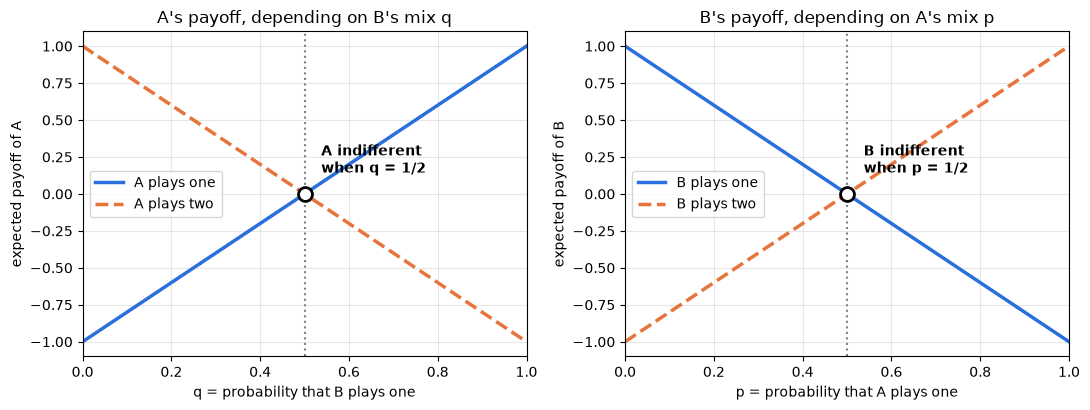

In [7]:
plot_indifference(game, acts, acts); plt.show()

**How to read the diagram.**

- **Left:** A's expected payoff for each of its two actions, depending on $q$ (how often B plays *one*).  
  Where the line of an action is higher, A prefers that action. Where the two lines cross, A is **indifferent**.
- **Right:** the same for B, depending on $p$ (how often A plays *one*).

In the mixed equilibrium, each player chooses the probability that puts the **other** player exactly on the crossing point:
B plays $q$ = the crossing value of the left panel, A plays $p$ = the crossing value of the right panel.

**Q3.** What do you conclude?

> **Solution.**  
> Each player shows one or two fingers with probability 1/2: the only strategy that cannot be exploited.